# MODEL

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_model = pd.read_csv(r'..\00_Data\00_Processed\df_model.csv')

In [3]:
outliers_col_list = [
    'age',
    'total_priors_count',
    'juv_priors_count',
]

for col in outliers_col_list:

    upper = df_model[col].quantile(0.99)

    no_outlier_df = df_model[
        df_model[col] <= upper
    ]

## Final Model

In [ ]:
drop_col_list = ['two_year_recid', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', "adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'sex', 'age_cat']

In [ ]:
features_num = ['age', 'juv_priors_count', 'adult_priors_freq_2']
features_bin = ['is_public_disorder', 'is_justice_related', 'is_sexual', 'is_drug', 'is_weapon', 'is_property', 'c_charge_degree', 'no_charge', 'is_fraud', 'is_violent', 'is_traffic']

scaler = StandardScaler()
df_model_scaled = no_outlier_df.copy()
df_model_scaled[features_num] = scaler.fit_transform(no_outlier_df[features_num])



Coeficientes:
               Variable  Coeficiente
13  adult_priors_freq_2     0.676972
1      juv_priors_count     0.223406
10   is_public_disorder     0.000000
11   is_justice_related     0.000000
9             is_sexual    -0.014954
4               is_drug    -0.081451
7             is_weapon    -0.091060
5           is_property    -0.161602
2       c_charge_degree    -0.166820
12            no_charge    -0.198536
6              is_fraud    -0.266155
3            is_violent    -0.307165
8            is_traffic    -0.345158
0                   age    -0.357012

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7314933675652546


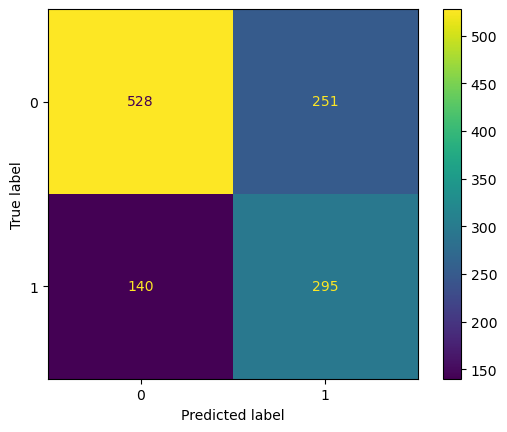

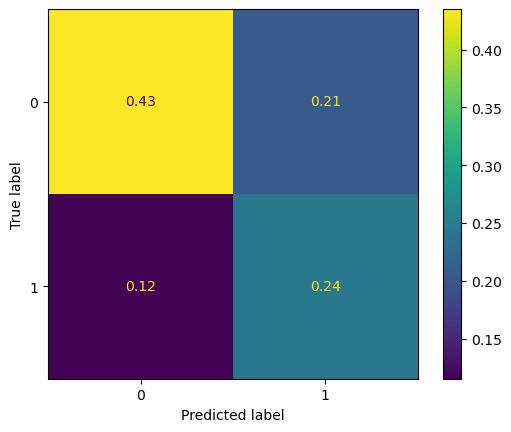

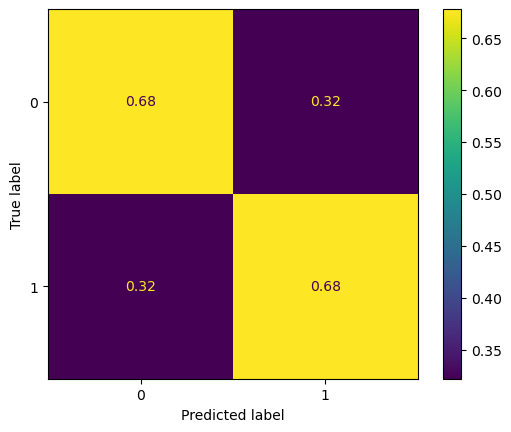


=== Raza: other ===


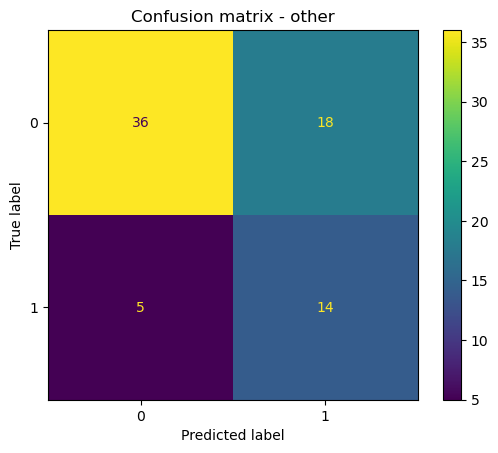

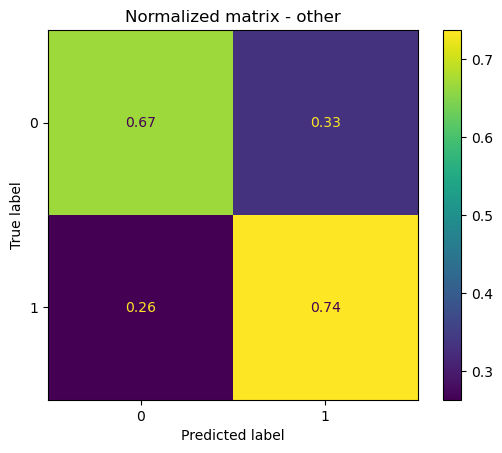

FPR: 0.333 | TPR: 0.737

=== Raza: african-american ===


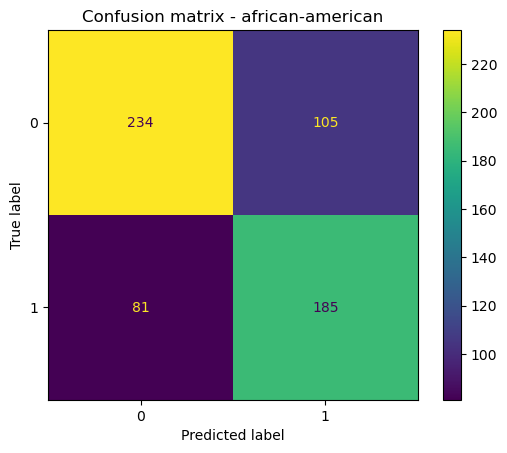

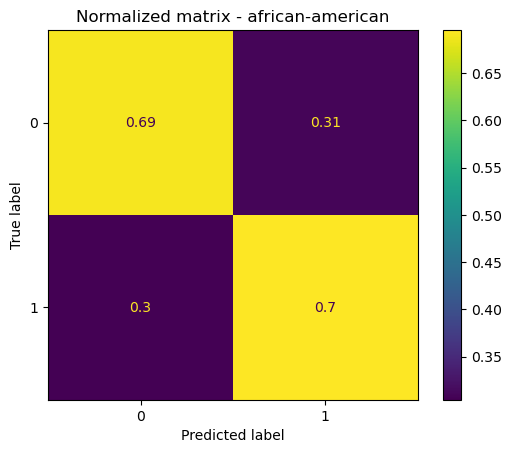

FPR: 0.310 | TPR: 0.695

=== Raza: hispanic ===


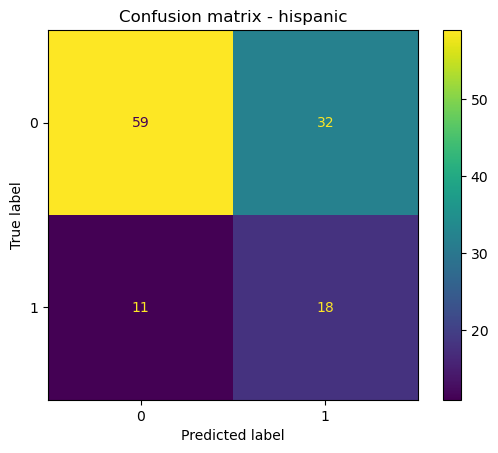

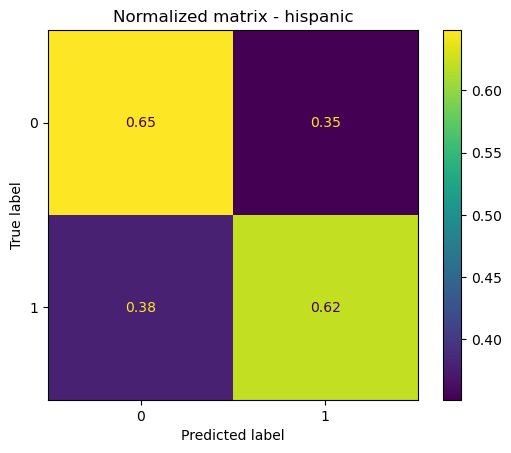

FPR: 0.352 | TPR: 0.621

=== Raza: caucasian ===


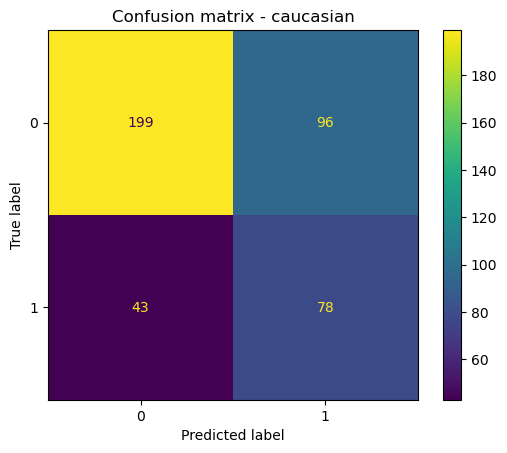

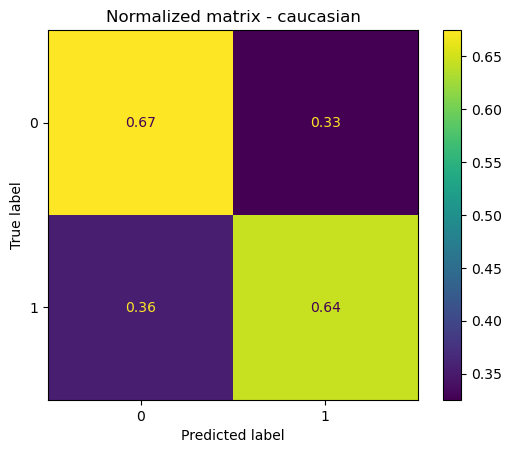

FPR: 0.325 | TPR: 0.645


In [ ]:
X = df_model_scaled.drop(columns=drop_col_list)
y = df_model_scaled['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)


person_id_test = X_test['person_id']

X_train = X_train.drop(columns=['person_id'])
X_test = X_test.drop(columns=['person_id'])

model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_proba = pd.Series(
    model.predict_proba(X_test)[:, 1],
    index=X_test.index
)

df_aux = no_outlier_df.set_index('person_id')

race_test = df_aux.loc[person_id_test, 'race']
sex_test = df_aux.loc[person_id_test, 'sex']
age_cat_test = df_aux.loc[person_id_test, 'age_cat']

# DataFrame to evaluate

df_eval = pd.DataFrame(index=X_test.index)

df_eval['person_id'] = person_id_test.values
df_eval['y_true'] = y_test.values
df_eval['race'] = race_test.values
df_eval['sex'] = sex_test.values
df_eval['age_cat'] = age_cat_test.values
df_eval['y_score'] = y_proba.values

# Thresholds by race

thresholds = {
    'african-american': 0.53,
    'caucasian': 0.45,
    'hispanic': 0.46,
    'other': 0.45
}

def apply_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(apply_threshold, axis=1)

y_pred = df_eval['y_pred'].values

coefficients = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': model.coef_[0]
})

print("\Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))


print("\nRanking report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

#create confusion matrices

races = df_eval['race'].unique()

for race in races:
    group = df_eval[df_eval['race'] == race]
    
    y_true_r = group['y_true']
    y_pred_r = group['y_pred']
    
    print(f"\n=== Raza: {race} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion matrix - {race}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Normalized matrix - {race}")
    plt.show()
    
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

In [ ]:
# To build dashboard

df_eval.to_csv(r'..\00_Data\00_Processed\df_eval.csv', index=False)
no_outlier_df.to_csv(r'..\00_Data\00_Processed\no_outlier_df.csv', index=False)